In [1]:
import sys
sys.path.append("/anvme/workspace/v120bb18-match/")
import os
import torch
import yaml
from dotmap import DotMap
from dataset import CHOLEC80,SCARED
from pipelines.odometry.odometry import OdometryPipeline
from pipelines.depth.depth import DepthPipeline
from pipelines.matching.matching import MatchingPipeline
from pipelines.depth.tsdf import TSDFVolume
import matplotlib.pyplot as plt
from utilities.visualization import viewComparePixelMatches,log_rerun_camera,rgb
import numpy as np
%load_ext autoreload
%autoreload 2

In [2]:
torch.cuda.is_available()

True

In [3]:
CONFIG_PATH = 'config_train.yaml'
with open(CONFIG_PATH, 'r') as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml['parameters']
    config_training_dict = {k: v.get('value') for k, v in config_parameters.items() if v is not None}
    config = DotMap(config_training_dict)


In [ ]:
dataset = SCARED(
    path="/home/shared/nearmrs/arota/SCARED/",
    # vids=["v33"],
    exclude=["val_"],
    frameskip=[32],
    fps = 32,
    random_pose=False,
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    unit_translation=False,
    with_intrinsics=True,
)
len(dataset)


25481

In [5]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1,shuffle=True)
iloader = iter(dataloader)
sample = next(iloader)
# Print sample keys and shapes
for k, v in sample.items():
    if hasattr(v, 'shape'):
        print(f'{k}: Tensor of shape {list(v.shape)}')
    else:
        print(f'{k}: {type(v)}')


idx: Tensor of shape [1]
framestack: Tensor of shape [1, 2, 3, 384, 384]
Ts2t: Tensor of shape [1, 6]
paths: <class 'list'>
frameskip: Tensor of shape [1]
fundamental: Tensor of shape [1, 1, 3, 3]


In [6]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1,shuffle=True)
iloader = iter(dataloader)
sample = next(iloader)
# Print sample keys and shapes
for k, v in sample.items():
    if hasattr(v, 'shape'):
        print(f'{k}: Tensor of shape {list(v.shape)}')
    else:
        print(f'{k}: {type(v)}')
rgbimage = sample["framestack"][:,0]

idx: Tensor of shape [1]
framestack: Tensor of shape [1, 2, 3, 384, 384]
Ts2t: Tensor of shape [1, 6]
paths: <class 'list'>
frameskip: Tensor of shape [1]
fundamental: Tensor of shape [1, 1, 3, 3]


xFormers not available
xFormers not available


Using cache found in /home/arota/.cache/torch/hub/facebookresearch_dinov2_main


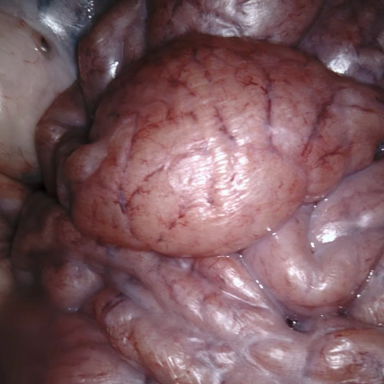

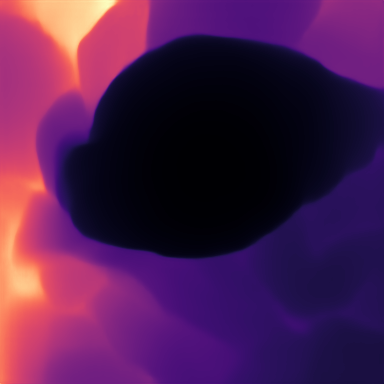

torch.Size([1, 1, 384, 384]) tensor(0., device='cuda:0') tensor(1., device='cuda:0')
tensor([[[268.8000,   0.0000, 192.0000],
         [  0.0000, 268.8000, 192.0000],
         [  0.0000,   0.0000,   1.0000]]], device='cuda:0')


In [7]:
from pipelines.geometry.geometry import GeometryPipeline
geometry_pipeline = GeometryPipeline(geometry_model_name="endosynth:dav1",device="cuda")
depthstack, _, K = geometry_pipeline.compute_geometry(rgbimage)
rgb(rgbimage)
rgb(depthstack)
print(depthstack.shape, depthstack.min(), depthstack.max())
print(K)

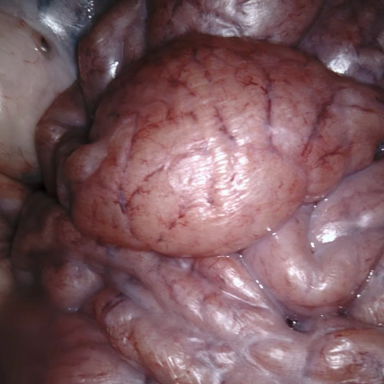

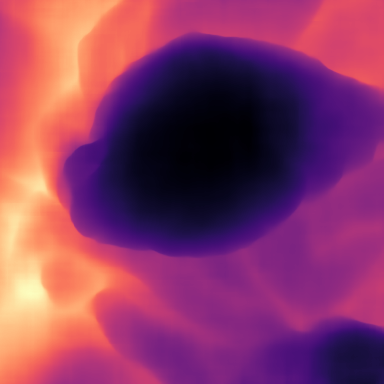

torch.Size([1, 1, 384, 384]) tensor(0., device='cuda:0') tensor(1., device='cuda:0')
tensor([[[506.8387,   0.0000, 192.0000],
         [  0.0000, 506.8387, 192.0000],
         [  0.0000,   0.0000,   1.0000]]], device='cuda:0')


In [8]:
from pipelines.geometry.geometry import GeometryPipeline
geometry_pipeline = GeometryPipeline(geometry_model_name="Ruicheng/moge-2-vits-normal",device="cuda")
depthstack, _, K = geometry_pipeline.compute_geometry(rgbimage)
rgb(rgbimage)
rgb(depthstack)
print(depthstack.shape, depthstack.min(), depthstack.max())
print(K)

/home/arota/Match/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


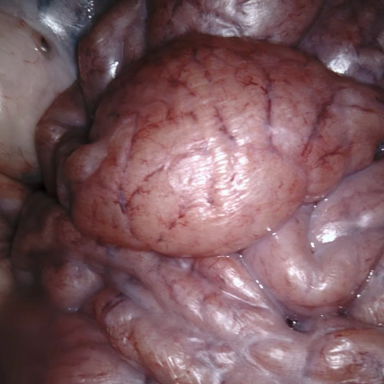

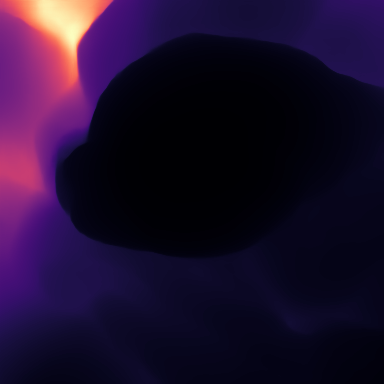

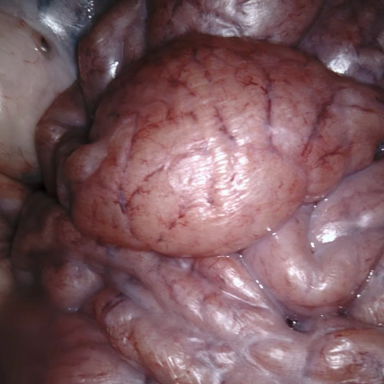

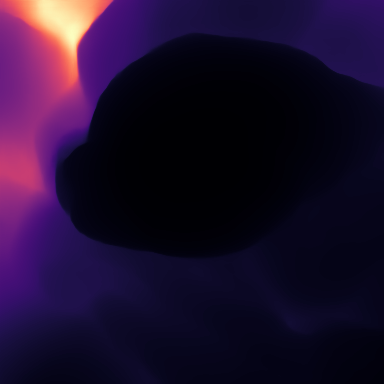

torch.Size([1, 1, 384, 384]) tensor(0., device='cuda:0') tensor(1., device='cuda:0')
tensor([[[268.8000,   0.0000, 192.0000],
         [  0.0000, 268.8000, 192.0000],
         [  0.0000,   0.0000,   1.0000]]], device='cuda:0')


In [9]:
from pipelines.geometry.geometry import GeometryPipeline
from dotenv import load_dotenv
load_dotenv()
geometry_pipeline = GeometryPipeline(geometry_model_name="Intel/dpt-large",device="cuda")
depthstack, _, K = geometry_pipeline.compute_geometry(rgbimage)
rgb(rgbimage)
rgb(depthstack)
rgb(rgbimage)
rgb(depthstack)
print(depthstack.shape, depthstack.min(), depthstack.max())
print(K)

In [10]:
print(sample["intrinsics"])

KeyError: 'intrinsics'